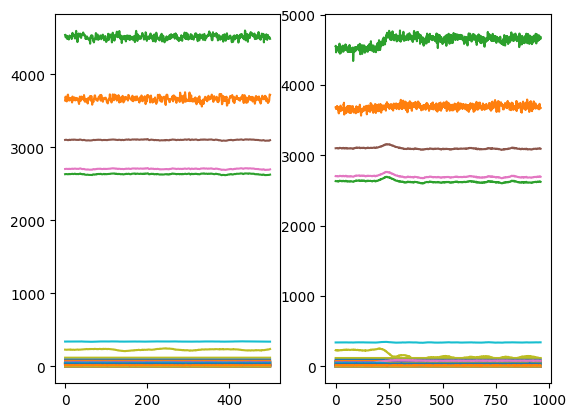

In [ ]:
# 导入TEP数据，特别注意一个坑，d00.dat数据的行列与其余所有文件相反
# d00代表正常数据
# d01-d021代表故障数据
# 带_te的是测试数据，不带的为训练数据，如果做故障检测，不需要使用故障数据训练，只使用正常数据
# 测试故障数据集中并非全部故障数据，故障在第160个采样点引入，训练故障集中全部为故障数据
# 导入相关package
import pandas as pd  
import matplotlib.pyplot as plt
df = pd.read_csv('./TEP_DATA/d00.dat', delim_whitespace=True, header=None)#！！！！注意，数据集中存在长度不一的空格间隔符，需要自适应
np_array_values = df.values.T  #!!!!!!!!!!!!!!!!!!!!!除了这个文件需要转职，其余文件均不需要，这里np_array_values里面存放的是正常训练数据
np_array_values.shape
plt.subplot(1,2,1)
plt.plot(np_array_values[:,:])

df = pd.read_csv('./TEP_DATA/d02_te.dat', delim_whitespace=True, header=None)
np_array_values_fault = df.values    #!!!!!!!!!!!!!!!!!!!!!这里存放的是故障2测试数据，如果希望导入其他数据，按文件夹内文件名字修改
plt.subplot(1,2,2)
plt.plot(np_array_values_fault[:,:])
plt.show()

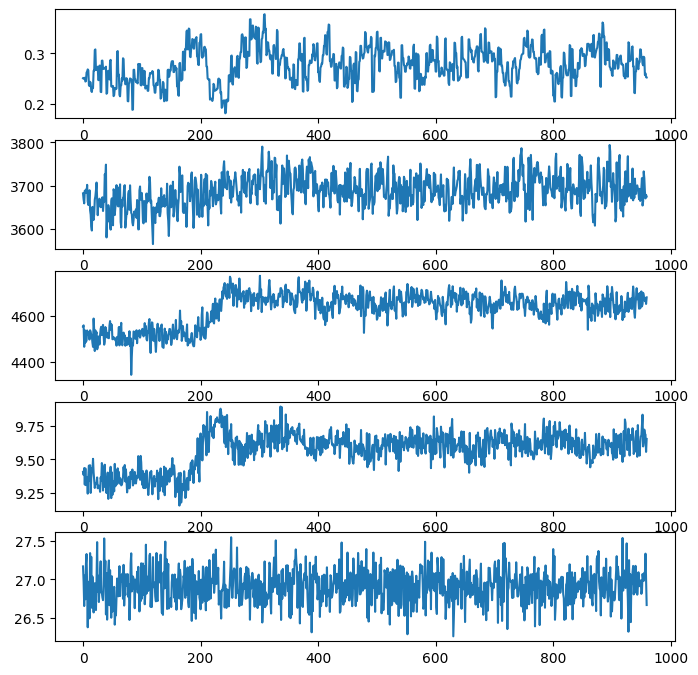

In [ ]:
plt.figure(figsize=(8, 15))
for i in range(5):
    plt.subplot(9,1,i+1)
    plt.plot(np_array_values_fault[:,i])    
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 假设 X 是你的训练数据，形状为 (480, 52)
# 这里用随机数据模拟，实际使用时替换为你的数据
X = np_array_values  # 替换为你的数据

# 手动标准化数据（均值为 0，方差为 1）
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X_scaled = (X - mean) / std

# 转换为 PyTorch 张量
X_tensor = torch.FloatTensor(X_scaled)

# 定义自编码器模型
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Autoencoder, self).__init__()
        # 编码器
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        # 解码器
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # 如果数据在 [0,1] 范围内，可以用 Sigmoid
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# 初始化模型
input_dim = 52
hidden_dim = 30
model = Autoencoder(input_dim, hidden_dim)

# 定义损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练模型
epochs = 100
for epoch in range(epochs):
    # 前向传播
    outputs = model(X_tensor)
    loss = criterion(outputs, X_tensor)
    
    # 反向传播和优化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')

# 计算重构误差
with torch.no_grad():
    reconstructed = model(X_tensor)
    reconstruction_error = criterion(reconstructed, X_tensor)
    print(f'Final Reconstruction Error: {reconstruction_error.item():.4f}')

# 如果需要，可以将重构误差保存或进一步分析

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch [10/100], Loss: 1.2299
Epoch [20/100], Loss: 1.2001
Epoch [30/100], Loss: 1.1675
Epoch [40/100], Loss: 1.1315
Epoch [50/100], Loss: 1.0930
Epoch [60/100], Loss: 1.0547
Epoch [70/100], Loss: 1.0196
Epoch [80/100], Loss: 0.9895
Epoch [90/100], Loss: 0.9648
Epoch [100/100], Loss: 0.9449
Final Reconstruction Error: 0.9431


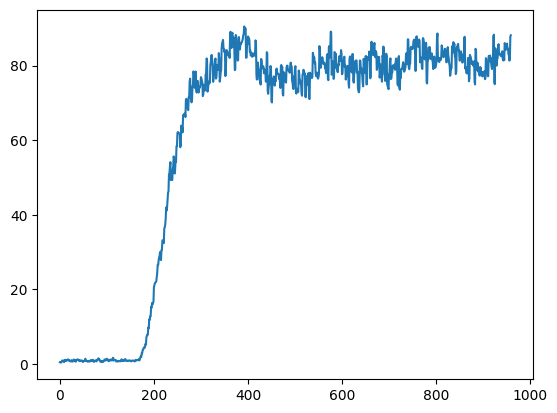

In [ ]:
X = np_array_values_fault  # 替换为你的数据

# 手动标准化数据（均值为 0，方差为 1）
X_scaled = (X - mean) / std

# 转换为 PyTorch 张量
X_tensor = torch.FloatTensor(X_scaled) 
reconstructed = model(X_tensor)
diff = X_tensor - reconstructed
    # 检测 
squared_diff = diff ** 2  

    # 对每行求均值，得到每行的MSE  
mse_per_row = squared_diff.mean(dim=1) 
mse_np = mse_per_row.detach().numpy()
plt.plot(mse_np)
plt.show()

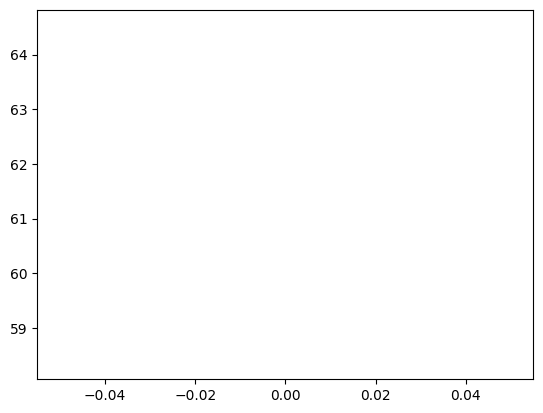

In [ ]:
plt.plot(reconstruction_error.detach().numpy())
plt.show()